In [ ]:
import logging
import multiprocessing
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.model_selection import train_test_split

from gensim.models import Word2Vec
from gensim.utils import RULE_DEFAULT, RULE_KEEP
from gensim.models.callbacks import CallbackAny2Vec

from arxivML import utils_ml 
from arxivML import utils_word 

from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

In [ ]:
plt.style.use('tableau-colorblind10')
def plot_style():
    font_size       = 12
    dpi             = 200

    params = {'figure.dpi': dpi,
              'savefig.dpi': dpi,
              'font.size': font_size,
              'font.family': "serif",
              'figure.titlesize': font_size,
              'legend.fontsize': font_size,
              'axes.labelsize': font_size,
              'axes.titlesize': font_size,
              'xtick.labelsize': font_size,
              'ytick.labelsize': font_size,
              'text.usetex': True,
             }

    plt.rcParams.update(params)
plot_style()

# baseline based on cos similarity of 2 embeddings

In [2]:
ngram_abstracts = np.load("saved_files/ngram_abstracts.npy", mmap_mode="r")
filtered_concept_arr = np.unique(np.load("saved_files/overlapping_filtered_5_concepts.npy"))
year_arr = np.load("saved_files/year_arr.npy", mmap_mode="r")

In [ ]:
word_co_occurrences = utils_word.get_word_co_occurrences(filtered_concept_arr, ngram_abstracts, year_arr)

100%|██████████| 63091/63091 [00:03<00:00, 18167.11it/s]


In [4]:
load = True  
phys_concept_dict = {k: 1 for k in filtered_concept_arr}

year_train = 2017 #train_label_years => [2018, 2019, 2020]
year_test = 2020 # test_label_years => [2021, 2022, 2023]
if not load:
    df_ab = pd.DataFrame(data=ngram_abstracts,    # values
                columns=["ab"])  # 1st row as the column names
    df_ab["year"] = year_arr

    # Custom rule function
    def custom_rule(word, count, min_count):
        if word in phys_concept_dict:
            return RULE_KEEP
        else:
            return RULE_DEFAULT

    cores = multiprocessing.cpu_count()

    class LossLogger(CallbackAny2Vec):
        '''Callback to log loss after each epoch.'''
        def __init__(self):
            self.epoch = 0
            self.losses = []
            self.previous_loss = 0
            self.initial_loss = 0

        def on_epoch_begin(self, model):
            # Record the initial loss at the start of each epoch
            self.initial_loss = model.get_latest_training_loss()

        def on_epoch_end(self, model):
            current_loss = model.get_latest_training_loss()
            # Calculate the loss for the current epoch
            loss = current_loss - self.initial_loss
            self.losses.append(loss)
            self.initial_loss = current_loss  # Reset for the next epoch
            self.epoch += 1

    ngram_abstracts_year = [ab.split() for ab in df_ab[df_ab['year'] <= year_train]["ab"].to_numpy()]
    loss_logger = LossLogger()
    w2v_model = Word2Vec(min_count=5,
                        window=15,
                        vector_size=128,
                        sample=1e-4, 
                        alpha=0.01, 
                        min_alpha= 0.0001, 
                        negative=15,
                        workers=cores-1)
    # Build the vocabulary on the first year's data
    w2v_model.build_vocab(ngram_abstracts_year, trim_rule=custom_rule)
    w2v_model.train(ngram_abstracts_year, total_examples=w2v_model.corpus_count, epochs=50, compute_loss=True, callbacks=[loss_logger])
    w2v_model.save(f"saved_w2v_models/baseline_train_model_{year_train}.model")

    ngram_abstracts_year = [ab.split() for ab in df_ab[df_ab['year'] <= year_test]["ab"].to_numpy()]
    loss_logger = LossLogger()
    w2v_model = Word2Vec(min_count=5,
                        window=15,
                        vector_size=128,
                        sample=1e-4, 
                        alpha=0.01, 
                        min_alpha= 0.0001, 
                        negative=15,
                        workers=cores-1)
    # Build the vocabulary on the first year's data
    w2v_model.build_vocab(ngram_abstracts_year, trim_rule=custom_rule)
    w2v_model.train(ngram_abstracts_year, total_examples=w2v_model.corpus_count, epochs=50, compute_loss=True, callbacks=[loss_logger])
    w2v_model.save(f"saved_w2v_models/baseline_test_model_{year_test}.model")

In [ ]:
baseline_1_train_encoding_arr, baseline_1_train_c_arr = utils_word.get_baseline_1_embeddings(Word2Vec.load(f"saved_w2v_models/baseline_train_model_{year_train}.model"),filtered_concept_arr)

baseline_1_test_encoding_arr, baseline_1_test_c_arr = utils_word.get_baseline_1_embeddings(Word2Vec.load(f"saved_w2v_models/baseline_test_model_{year_test}.model"),filtered_concept_arr)


Found 9934 vectors, missed 301 vectors.
Found 10172 vectors, missed 63 vectors.


In [ ]:
def create_dataset_indexing(data: np.ndarray, word_co_occurrences: dict, year_arr: np.ndarray, c_inx_arr: np.ndarray, 
                 input_window_size: int = 5, output_window_size: int = 3, offset_to_current_year: int = 1):
    """
    Dataset indexing for time series data.

    Args:
        data (np.ndarray): The input data.
        word_co_occurrences (dict): Dictionary of word co-occurrences.
        year_arr (np.ndarray): Array of years.
        c_inx_arr (np.ndarray): Array of concept indices.
        input_window_size (int, optional): Size of the input window. Defaults to 5.
        output_window_size (int, optional): Size of the output window. Defaults to 3.
        offset_to_current_year (int, optional): Offset to the current year. Defaults to 1.
        print_test (bool, optional): Whether to print test information. Defaults to False.

    Returns:
        np.ndarray: Positive index pair array.
        np.ndarray: Negative index pair array.
    """
    train_window_data = data[:, -input_window_size-output_window_size-offset_to_current_year:-output_window_size-offset_to_current_year]
    label_year_range = (year_arr[-output_window_size:] if offset_to_current_year == 0 
                                else year_arr[-output_window_size-offset_to_current_year:-offset_to_current_year])

    co_occur_concept_pair_arr = utils_word.get_co_occur_concept_pair_after_year_arr(
        word_co_occurrences, label_year_range[0], label_year_range[-1])
    
    print(f"Training Window: {utils_word.get_years_range(year_arr,-input_window_size-output_window_size-offset_to_current_year, -output_window_size-offset_to_current_year)}")
    print(f"Label Window: {utils_word.get_years_range(year_arr, -output_window_size-offset_to_current_year, -offset_to_current_year)}")

    # Precompute indices for each unique concept in c_inx_arr
    concept_to_indices = {concept: np.where(c_inx_arr == concept)[0] for concept in np.unique(c_inx_arr)}

    # Convert word_co_occurrences to a dictionary of sets for fast membership checking
    word_co_occurrences_set = {k: set(v) for k, v in word_co_occurrences.items()}

    pos_inx_pair_arr = np.zeros((len(co_occur_concept_pair_arr),2), dtype=int)
    
    for inx, pair in enumerate(co_occur_concept_pair_arr):
        try:
            pos_inx_pair_arr[inx, 0] = concept_to_indices[pair[0]][0]
            pos_inx_pair_arr[inx, 1] = concept_to_indices[pair[1]][0]
        except:
            pos_inx_pair_arr[inx, 0] = 0
            pos_inx_pair_arr[inx, 1] = 0
            
    
    pos_inx_pair_arr = pos_inx_pair_arr[~((pos_inx_pair_arr[:, 0] == 0) & (pos_inx_pair_arr[:, 1] == 0))]


    print("Finished Positives")
    
    neg_inx_pair_arr = np.zeros((len(pos_inx_pair_arr), 2), dtype=int)
    checked_pairs = set()
    neg_inx = 0

    while neg_inx < len(pos_inx_pair_arr):
        sampled_pair = tuple(np.random.choice(train_window_data.shape[0], size=2, replace=False))
        
        # Ensure the sampled pair is not the same and hasn't been checked before
        if sampled_pair not in checked_pairs:
            checked_pairs.add(sampled_pair)
            concept_0, concept_1 = c_inx_arr[sampled_pair[0]], c_inx_arr[sampled_pair[1]]

            if concept_1 not in word_co_occurrences_set.get(concept_0, set()):
                neg_inx_pair_arr[neg_inx, 0] = concept_to_indices[concept_0][0]
                neg_inx_pair_arr[neg_inx, 1] = concept_to_indices[concept_1][0]
                neg_inx += 1
    print("Finished Negatives")
    
    save_pos_arr = [word_co_occurrences[c_inx_arr[pos_inx_pair_arr[_][0]]][c_inx_arr[pos_inx_pair_arr[_][1]]] for _ in range(len(pos_inx_pair_arr))]
    save_neg_arr = [c_inx_arr[neg_inx_pair_arr[_][1]] in word_co_occurrences[c_inx_arr[neg_inx_pair_arr[_][0]]] for _ in range(len(neg_inx_pair_arr))]

    save_pos_arr = [x for xs in save_pos_arr for x in xs]
    
    print("Positive: Expect to be years: ", np.unique(save_pos_arr))
    print("Negative: Expect to be 0: ", np.sum(save_neg_arr))


    return pos_inx_pair_arr, neg_inx_pair_arr


seq_length = 1
out_length = 3
batch_size = 128

train_pos_inx_pair_arr_3_3, train_neg_inx_pair_arr_3_3 = create_dataset_indexing(data=baseline_1_train_encoding_arr, word_co_occurrences=word_co_occurrences, year_arr = np.unique(year_arr), 
                            c_inx_arr=baseline_1_train_c_arr, input_window_size = seq_length, output_window_size = out_length, offset_to_current_year = 3)

test_pos_inx_pair_arr_3_0, test_neg_inx_pair_arr_3_0 = create_dataset_indexing(data=baseline_1_test_encoding_arr, word_co_occurrences=word_co_occurrences, year_arr = np.unique(year_arr), 
                            c_inx_arr=baseline_1_test_c_arr, input_window_size = seq_length, output_window_size = out_length, offset_to_current_year = 0)


Training Window: [2017]
Label Window: [2018 2019 2020]
Finished Positives
Finished Negatives
Positive: Expect to be years:  [2018 2019 2020]
Negative: Expect to be 0:  0
Training Window: [2020]
Label Window: [2021 2022 2023]
Finished Positives
Finished Negatives
Positive: Expect to be years:  [2021 2022 2023]
Negative: Expect to be 0:  0


In [ ]:
class CustomBaselineDataset(Dataset):
    def __init__(self, train_window_data, pair_arr, labels):
        self.train_window_data = train_window_data
        self.pair_arr = pair_arr
        self.labels = labels
        self.shape = self.train_window_data.shape

    def __len__(self):
        return len(self.pair_arr)

    def __getitem__(self, idx):
        
        inx_0, inx_1 = self.pair_arr[idx]
        label = self.labels[idx]
        enc_0 = self.train_window_data[inx_0]
        enc_1 = self.train_window_data[inx_1]
        enc_01 = utils_word.similarity_cosine(enc_0, enc_1)
        
        return torch.from_numpy(enc_01), torch.tensor([label], dtype=torch.float32), inx_0, inx_1 

def create_train_val_datasets(train_window_data, pos_inx_pair_arr, neg_inx_pair_arr, test_size=0.2, random_state=42):
    # Create labels
    pos_labels = np.ones(len(pos_inx_pair_arr))
    neg_labels = np.zeros(len(neg_inx_pair_arr))
    
    # Concatenate positive and negative pairs and labels
    all_pairs = np.vstack((pos_inx_pair_arr, neg_inx_pair_arr))
    all_labels = np.concatenate((pos_labels, neg_labels))
    
    # Split indices into training and test sets
    train_idx, test_idx = train_test_split(
        np.arange(len(all_pairs)), test_size=test_size, random_state=random_state, stratify=all_labels
    )
    
    # Create training and test datasets
    train_dataset = CustomBaselineDataset(train_window_data, all_pairs[train_idx], all_labels[train_idx])
    test_dataset = CustomBaselineDataset(train_window_data, all_pairs[test_idx], all_labels[test_idx])
    
    return train_dataset, test_dataset

def create_test_datasets(train_window_data, pos_inx_pair_arr, neg_inx_pair_arr):
    # Create labels
    pos_labels = np.ones(len(pos_inx_pair_arr))
    neg_labels = np.zeros(len(neg_inx_pair_arr))
    
    # Concatenate positive and negative pairs and labels
    all_pairs = np.vstack((pos_inx_pair_arr, neg_inx_pair_arr))
    all_labels = np.concatenate((pos_labels, neg_labels))
     
    return CustomBaselineDataset(train_window_data, all_pairs, all_labels)

train_dataset, val_dataset = create_train_val_datasets(
    train_window_data=baseline_1_train_encoding_arr, pos_inx_pair_arr=train_pos_inx_pair_arr_3_3, neg_inx_pair_arr=train_neg_inx_pair_arr_3_3, test_size=0.2)

test_dataset = create_test_datasets(
    train_window_data=baseline_1_test_encoding_arr, pos_inx_pair_arr=test_pos_inx_pair_arr_3_0, neg_inx_pair_arr=test_neg_inx_pair_arr_3_0)


train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [ ]:
# Initialize logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Example usage
input_dim = 1 
model_mlp = utils_ml.MLP(input_dim)


criterion = nn.BCELoss()
optimizer = optim.Adam(model_mlp.parameters(), lr=0.005)
scheduler = CosineAnnealingLR(optimizer, T_max=10)

# train_model(model_mlp, train_dataloader, val_dataloader, criterion, optimizer, scheduler,file_name='saved_ml_models/best_baseline_1_model.pth')


In [9]:
model_mlp.load_state_dict(torch.load('saved_ml_models/best_baseline_1_model.pth'))
# plot_roc(model_mlp, test_dataloader)
# compute_roc(model_mlp, test_dataloader, filename="baseline_1")

RuntimeError: Error(s) in loading state_dict for MLP:
	Missing key(s) in state_dict: "output.1.weight". 

In [10]:
def compute_acc(model, dataloader):
    model.eval()
    all_labels = []
    all_probs = []
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data, labels, _, _ in dataloader:
            outputs = model(data.float())
            probs = outputs.cpu().numpy()
            predicted = (outputs > 0.5).float()  # Use 0.5 as threshold for binary classification
            
            total += labels.size(0)
            correct += (predicted.cpu() == labels.cpu()).sum().item()
            
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())

    # Calculate accuracy
    accuracy = correct / total

    return accuracy
compute_acc(model_mlp, test_dataloader)

0.556854632346051

In [ ]:
model = model_mlp
dataloader = test_dataloader
removal_steps = 95

model.eval()
all_probs = []
all_labels = []

# Get predictions and true labels
with torch.no_grad():
    for inputs, labels,_,_ in dataloader:
        inputs = inputs.to(next(model.parameters()).device)
        outputs = model(inputs.float())
        probs = outputs.cpu().numpy()  # Assuming binary classification
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())

# Convert lists to numpy arrays
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# print(all_labels.shape,all_probs.shape)

# Get absolute difference from 0.5 (uncertainty)
uncertainty = np.abs(all_probs - 0.5).flatten()
sorted_indices = np.argsort(uncertainty)

auc_scores = []
percentages_removed = np.linspace(0, 95, removal_steps)

for perc in percentages_removed:
    num_to_remove = int((perc / 100) * len(all_probs))
    
    remaining_indices = sorted_indices[num_to_remove:]
    auc_score = roc_auc_score(all_labels[remaining_indices], all_probs[remaining_indices])

    auc_scores.append(auc_score)


model.eval()  # Set the model to evaluation mode
all_probs = []
all_labels = []

with torch.no_grad():
    for inputs, labels, inx_0, inx_1 in dataloader:
        # Forward pass
        outputs = model(inputs.float())
        # Get probabilities (assuming a binary classification with sigmoid)
        probs = outputs.squeeze().cpu().numpy()
        labels = labels.cpu().numpy()
        
        all_probs.extend(probs)
        all_labels.extend(labels)

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# Compute the calibration curve
prob_true, prob_pred = calibration_curve(all_labels, all_probs, n_bins=100)


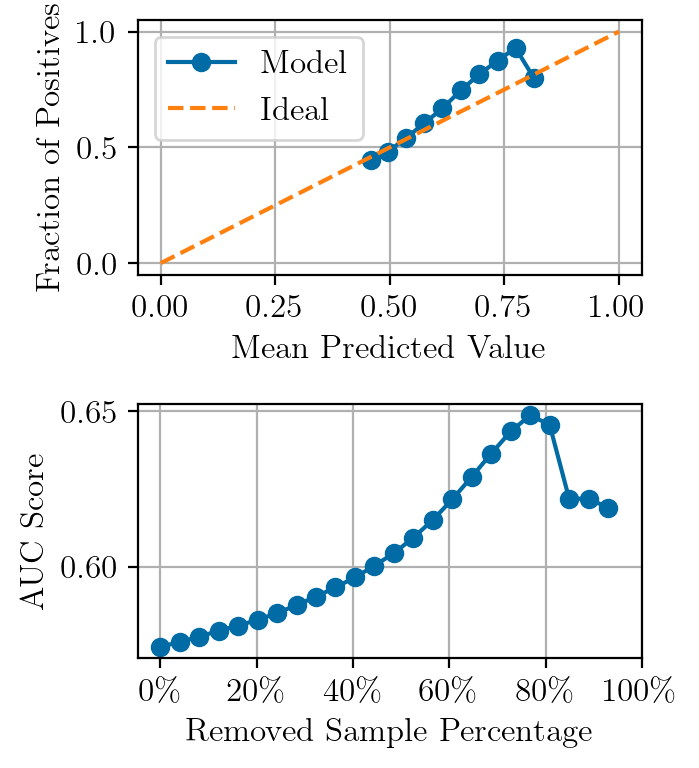

In [12]:
fig,axs = plt.subplots(2,1,figsize=(7.48031/2, 4))

axs[0].plot(prob_pred[::4], prob_true[::4], marker='o', label='Model')
axs[0].plot([0, 1], [0, 1], linestyle='--', label='Ideal')
axs[0].set_xlabel('Mean Predicted Value')
axs[0].set_ylabel('Fraction of Positives')
axs[0].legend(loc='best')
axs[0].grid()

axs[1].plot(percentages_removed[::4], auc_scores[::4], marker='o')
axs[1].set_xlabel('Removed Sample Percentage')
axs[1].set_ylabel('AUC Score')
axs[1].grid(True)

axs[1].set_xticks([0, 20, 40, 60, 80, 100])
axs[1].set_xticklabels([f"{int(p)}\%" for p in [0, 20, 40, 60, 80, 100]])
# axs[1].set_yticks([0.85,0.9,0.95])

# axs[0].text(0.96, 0.07, 'a',  ha='center', va='center', fontsize=16)
# axs[1].text(96, 0.86, 'b',  ha='center', va='center', fontsize=16)

plt.tight_layout()
# fig.savefig("figures/callibration_performance_1.pdf", format="pdf", bbox_inches="tight")

plt.show()